# **DAY 2**

In [1]:
"""
DAY 2 - PRACTICE 1: Understanding Pre-trained Models
Goal: Learn how to load and use pre-trained models
"""

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#  1. LIST AVAILABLE MODELS 
print("\n1. Available pre-trained models in torchvision...")

available_models = [
    'resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152',
    'vgg11', 'vgg13', 'vgg16', 'vgg19',
    'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2',
    'densenet121', 'densenet161'
]

print("Some available models:")
for model_name in available_models[:5]:
    print(f"  - {model_name}")


1. Available pre-trained models in torchvision...
Some available models:
  - resnet18
  - resnet34
  - resnet50
  - resnet101
  - resnet152


In [3]:
#  2. LOAD PRE-TRAINED RESNET 
print("\n2. Loading pre-trained ResNet18...")

# Load pre-trained model
model = models.resnet18(weights='IMAGENET1K_V1')
print("Model loaded successfully!")
print(f"Model type: {type(model)}")


2. Loading pre-trained ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s] 


Model loaded successfully!
Model type: <class 'torchvision.models.resnet.ResNet'>


In [4]:
#  3. EXPLORE MODEL ARCHITECTURE 

print("Model structure:")
# Print first few layers
for name, layer in list(model.named_children())[:5]:
    print(f"Layer: {name}")
    print(f"  Type: {type(layer)}")
    if hasattr(layer, 'in_features'):
        print(f"  Input features: {layer.in_features}")
    if hasattr(layer, 'out_features'):
        print(f"  Output features: {layer.out_features}")
    print()

Model structure:
Layer: conv1
  Type: <class 'torch.nn.modules.conv.Conv2d'>

Layer: bn1
  Type: <class 'torch.nn.modules.batchnorm.BatchNorm2d'>

Layer: relu
  Type: <class 'torch.nn.modules.activation.ReLU'>

Layer: maxpool
  Type: <class 'torch.nn.modules.pooling.MaxPool2d'>

Layer: layer1
  Type: <class 'torch.nn.modules.container.Sequential'>



In [5]:
#  4. UNDERSTAND FINAL LAYER 
print(f"Original final layer: {model.fc}")
print(f"Input features: {model.fc.in_features}")
print(f"Output features: {model.fc.out_features} (ImageNet has 1000 classes)")

Original final layer: Linear(in_features=512, out_features=1000, bias=True)
Input features: 512
Output features: 1000 (ImageNet has 1000 classes)


In [6]:
#  5. REPLACE FINAL LAYER 
print("\n5. Replacing final layer for custom classification...")
num_classes = 10  # For CIFAR-10
# Replace the final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)
print(f"New final layer: {model.fc}")


5. Replacing final layer for custom classification...
New final layer: Linear(in_features=512, out_features=10, bias=True)


In [7]:
#  6. FREEZE LAYERS 
print("\n6. Freezing pre-trained layers...")
def freeze_layers(model, freeze_all=True):
    """Freeze layers for transfer learning"""
    if freeze_all:
        # Freeze all layers
        for param in model.parameters():
            param.requires_grad = False
        # Unfreeze the final layer
        for param in model.fc.parameters():
            param.requires_grad = True
        print("All layers frozen except the final layer")
    else:
        print("All layers trainable (fine-tuning)")
    return model

# Freeze layers
model = freeze_layers(model, freeze_all=True)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Percentage trainable: {100 * trainable_params / total_params:.2f}%")


6. Freezing pre-trained layers...
All layers frozen except the final layer

Total parameters: 11,181,642
Trainable parameters: 5,130
Percentage trainable: 0.05%


In [8]:
#  7. PREPARE DATA FOR INFERENCE 
print("\n7. Preparing pre-processing pipeline...")

# ImageNet normalization
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform pipeline created:")
for t in transform.transforms:
    print(f"  - {t}")


7. Preparing pre-processing pipeline...
Transform pipeline created:
  - Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
  - CenterCrop(size=(224, 224))
  - ToTensor()
  - Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


In [9]:
#  8. LOAD IMAGENET CLASSES 
print("\n8. Loading ImageNet class names...")

# Download ImageNet class names
import json
import urllib.request

url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
try:
    with urllib.request.urlopen(url) as response:
        imagenet_classes = json.loads(response.read().decode())
    print(f"Loaded {len(imagenet_classes)} ImageNet classes")
    print(f"First 10 classes: {imagenet_classes[:10]}")
except:
    print("Could not download ImageNet classes")
    imagenet_classes = None

print("\n✅ Practice 1 Complete!")
print("- Pre-trained models save training time")
print("- You can replace the final layer for your task")
print("- Freezing layers helps with small datasets")


8. Loading ImageNet class names...
Loaded 1000 ImageNet classes
First 10 classes: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead shark', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']

✅ Practice 1 Complete!
- Pre-trained models save training time
- You can replace the final layer for your task
- Freezing layers helps with small datasets


In [10]:
"""
DAY 2 - PRACTICE 2: Feature Extraction vs Fine-tuning
Goal: Compare both transfer learning approaches
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [11]:
#  1. SETUP 
print("\n1. Setting up CIFAR-10 dataset...")

# Transformations
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")


1. Setting up CIFAR-10 dataset...


100%|██████████| 170M/170M [1:07:48<00:00, 41.9kB/s] 


Training samples: 50000
Test samples: 10000


In [12]:
#  2. FEATURE EXTRACTION 
print("\n2. Feature Extraction approach...")

def feature_extraction_model():
    """Setup model for feature extraction"""
    model = models.resnet18(weights='IMAGENET1K_V1')
    
    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    
    # Replace final layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 10)
    
    return model

feature_model = feature_extraction_model()
print("Feature extraction model created")
print(f"Trainable parameters: {sum(p.numel() for p in feature_model.parameters() if p.requires_grad):,}")


2. Feature Extraction approach...
Feature extraction model created
Trainable parameters: 5,130


In [13]:
#  3. FINE-TUNING 
print("\n3. Fine-tuning approach...")

def fine_tuning_model():
    """Setup model for fine-tuning"""
    model = models.resnet18(weights='IMAGENET1K_V1')
    
    # Replace final layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 10)
    
    # All layers trainable (with different learning rates)
    return model

fine_model = fine_tuning_model()
print("Fine-tuning model created")
print(f"Trainable parameters: {sum(p.numel() for p in fine_model.parameters() if p.requires_grad):,}")


3. Fine-tuning approach...
Fine-tuning model created
Trainable parameters: 11,181,642


In [14]:
#  4. DIFFERENT LEARNING RATES 
print("\n4. Setting different learning rates...")

def setup_optimizer(model, approach='feature_extraction'):
    """Setup optimizer with appropriate learning rates"""
    
    if approach == 'feature_extraction':
        # Only train the final layer
        optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
        print("Optimizer: Only training final layer (lr=0.001)")
    
    else:  # fine-tuning
        # Separate parameters for different learning rates
        fc_params = []
        other_params = []
        
        for name, param in model.named_parameters():
            if param.requires_grad:
                if 'fc' in name:
                    fc_params.append(param)
                else:
                    other_params.append(param)
        
        optimizer = optim.SGD([
            {'params': other_params, 'lr': 0.001},   # Lower LR for pre-trained
            {'params': fc_params, 'lr': 0.01}        # Higher LR for new layers
        ], momentum=0.9, weight_decay=1e-4)
        print("Optimizer: Different LRs (0.001 for pre-trained, 0.01 for new)")
    
    return optimizer


4. Setting different learning rates...


In [15]:
#  5. COMPARE MODELS 
print("\n5. Quick comparison (1 epoch each)...")

def train_one_epoch(model, train_loader, approach_name):
    """Train for one epoch and return accuracy"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = setup_optimizer(model, approach_name)
    
    model.train()
    correct = 0
    total = 0
    start_time = time.time()
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    elapsed = time.time() - start_time
    
    return accuracy, elapsed

# Test both approaches
print("\nTesting Feature Extraction...")
fe_acc, fe_time = train_one_epoch(feature_model, train_loader, 'feature_extraction')
print(f"Feature Extraction: {fe_acc:.2f}% in {fe_time:.2f}s")

print("\nTesting Fine-tuning...")
fine_acc, fine_time = train_one_epoch(fine_model, train_loader, 'finetune')
print(f"Fine-tuning: {fine_acc:.2f}% in {fine_time:.2f}s")


5. Quick comparison (1 epoch each)...

Testing Feature Extraction...
Optimizer: Only training final layer (lr=0.001)
Feature Extraction: 53.06% in 123.94s

Testing Fine-tuning...
Optimizer: Different LRs (0.001 for pre-trained, 0.01 for new)
Fine-tuning: 68.57% in 222.93s



6. Visualizing differences...


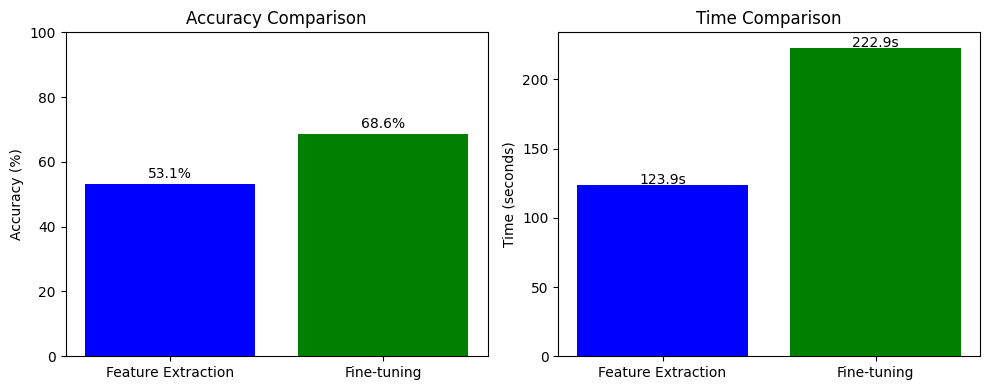


✅ Practice 2 Complete!
- Feature Extraction: Faster, less data needed
- Fine-tuning: Better performance with more data
- Choose approach based on dataset size


In [16]:
#  6. VISUALIZE DIFFERENCES 
print("\n6. Visualizing differences...")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Approach comparison
methods = ['Feature Extraction', 'Fine-tuning']
accuracies = [fe_acc, fine_acc]
times = [fe_time, fine_time]

axes[0].bar(methods, accuracies, color=['blue', 'green'])
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 2, f'{v:.1f}%', ha='center')

axes[1].bar(methods, times, color=['blue', 'green'])
axes[1].set_title('Time Comparison')
axes[1].set_ylabel('Time (seconds)')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.5, f'{v:.1f}s', ha='center')

plt.tight_layout()
plt.savefig('day2_practice2_comparison.png', dpi=150)
plt.show()

print("\n✅ Practice 2 Complete!")
print("- Feature Extraction: Faster, less data needed")
print("- Fine-tuning: Better performance with more data")
print("- Choose approach based on dataset size")

In [17]:
"""
DAY 2 - PRACTICE 3: Complete Transfer Learning Pipeline
Goal: Build a complete transfer learning system
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

In [18]:
#  1. CONFIGURATION 
print("\n1. Configuring the pipeline...")

class Config:
    # Data
    BATCH_SIZE = 32
    NUM_WORKERS = 4
    
    # Model
    MODEL_NAME = 'resnet18'  # Can change to 'resnet50', 'efficientnet_b0'
    NUM_CLASSES = 10
    
    # Training
    EPOCHS = 5
    LEARNING_RATE = 0.001
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Paths
    MODEL_SAVE_PATH = 'best_transfer_model.pth'

print(f"Configuration:")
print(f"  Device: {Config.DEVICE}")
print(f"  Model: {Config.MODEL_NAME}")
print(f"  Batch Size: {Config.BATCH_SIZE}")
print(f"  Epochs: {Config.EPOCHS}")


1. Configuring the pipeline...
Configuration:
  Device: cuda
  Model: resnet18
  Batch Size: 32
  Epochs: 5


In [19]:
#  2. DATA LOADING 
print("\n2. Loading data with augmentation...")

def get_transforms():
    """Get augmentation transforms"""
    mean = [0.4914, 0.4822, 0.4465]
    std = [0.2023, 0.1994, 0.2010]
    
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    return train_transform, val_transform

train_transform, val_transform = get_transforms()

# Load data
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, 
                         shuffle=True, num_workers=Config.NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, 
                        shuffle=False, num_workers=Config.NUM_WORKERS)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")



2. Loading data with augmentation...
Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [20]:
#  3. MODEL SETUP 
print("\n3. Setting up model...")

def setup_model(num_classes=10):
    """Setup pre-trained model with transfer learning"""
    
    if Config.MODEL_NAME == 'resnet18':
        model = models.resnet18(weights='IMAGENET1K_V1')
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, num_classes)
    
    elif Config.MODEL_NAME == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1')
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, num_classes)
    
    elif Config.MODEL_NAME == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        num_features = model.classifier[1].in_features
        model.classifier = nn.Linear(num_features, num_classes)
    
    else:
        raise ValueError(f"Unknown model: {Config.MODEL_NAME}")
    
    return model

model = setup_model()
print(f"Model: {Config.MODEL_NAME}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


3. Setting up model...
Model: resnet18
Total parameters: 11,181,642


In [21]:
#  4. TRAINING FUNCTIONS 
print("\n4. Setting up training functions...")

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if batch_idx % 50 == 49:
            print(f"  Batch {batch_idx+1}: Loss: {running_loss/50:.4f}")
            running_loss = 0.0
    
    return 100 * correct / total

def validate(model, val_loader, criterion, device):
    """Validate model"""
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return val_loss / len(val_loader), 100 * correct / total


4. Setting up training functions...


In [22]:
#  5. TRAINING LOOP 
print("\n5. Starting training...")

device = Config.DEVICE
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

best_acc = 0.0
history = {'train_acc': [], 'val_acc': [], 'val_loss': []}

start_time = time.time()

for epoch in range(Config.EPOCHS):
    print(f"\nEpoch {epoch+1}/{Config.EPOCHS}")
    print("-" * 40)
    
    # Train
    train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, test_loader, criterion, device)
    
    # Save history
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)
    
    # Print results
    print(f"Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}%, Val Loss: {val_loss:.4f}")
    
    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)
        print(f"✓ Best model saved! (Acc: {best_acc:.2f}%)")

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.2f} minutes")
print(f"Best Validation Accuracy: {best_acc:.2f}%")



5. Starting training...

Epoch 1/5
----------------------------------------
  Batch 50: Loss: 1.6694
  Batch 100: Loss: 1.2109
  Batch 150: Loss: 1.1420
  Batch 200: Loss: 1.0017
  Batch 250: Loss: 0.9899
  Batch 300: Loss: 0.9208
  Batch 350: Loss: 0.9144
  Batch 400: Loss: 0.8578
  Batch 450: Loss: 0.8494
  Batch 500: Loss: 0.8944
  Batch 550: Loss: 0.8244
  Batch 600: Loss: 0.8314
  Batch 650: Loss: 0.7920
  Batch 700: Loss: 0.8238
  Batch 750: Loss: 0.7956
  Batch 800: Loss: 0.6897
  Batch 850: Loss: 0.7064
  Batch 900: Loss: 0.7020
  Batch 950: Loss: 0.7364
  Batch 1000: Loss: 0.6955
  Batch 1050: Loss: 0.6096
  Batch 1100: Loss: 0.6665
  Batch 1150: Loss: 0.6506
  Batch 1200: Loss: 0.5865
  Batch 1250: Loss: 0.6380
  Batch 1300: Loss: 0.6485
  Batch 1350: Loss: 0.6318
  Batch 1400: Loss: 0.5847
  Batch 1450: Loss: 0.6202
  Batch 1500: Loss: 0.5965
  Batch 1550: Loss: 0.5896
Train Acc: 72.49%
Val Acc: 80.16%, Val Loss: 0.5814
✓ Best model saved! (Acc: 80.16%)

Epoch 2/5
---------


6. Visualizing results...


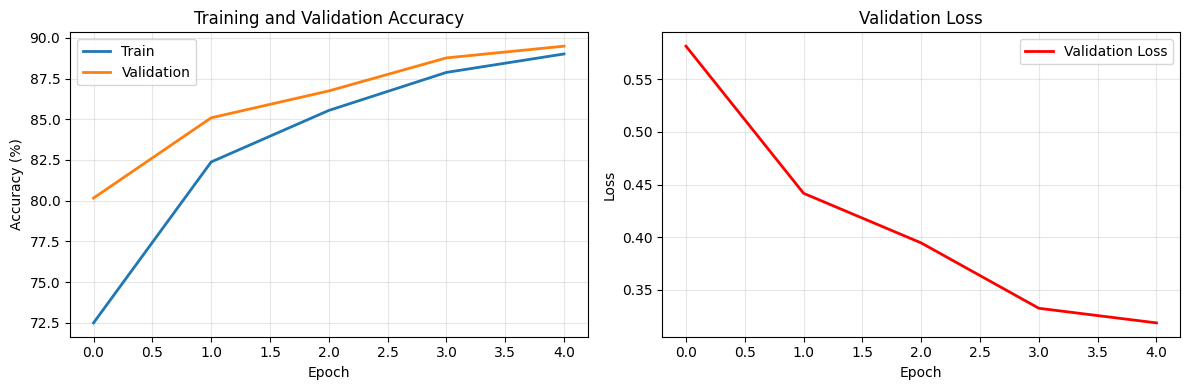


✅ DAY 2 COMPLETE!
- Learned about pre-trained models
- Understood feature extraction vs fine-tuning
- Built a complete transfer learning pipeline
- Achieved good accuracy on CIFAR-10


In [26]:
#  6. VISUALIZATION 
print("\n6. Visualizing results...")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history['train_acc'], label='Train', linewidth=2)
axes[0].plot(history['val_acc'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Training and Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history['val_loss'], label='Validation Loss', linewidth=2, color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('day2_practice3_training_history.png', dpi=150)
plt.show()

print("\n✅ DAY 2 COMPLETE!")
print("- Learned about pre-trained models")
print("- Understood feature extraction vs fine-tuning")
print("- Built a complete transfer learning pipeline")
print("- Achieved good accuracy on CIFAR-10")